In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('../../jupyter_notebooks/DATA/bank-full.csv')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,subscribed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [4]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


## Begin exploratory analysis
Since there are no problems that call for feature engineering and the data seem quite clean, we can now start exploratory analysis with the help of domain knowledge.

We'll look at different columns and banking data that might be suitable for separating the total into groups like: age, education, employment, having or not a loan, etc.

<Axes: xlabel='age', ylabel='Count'>

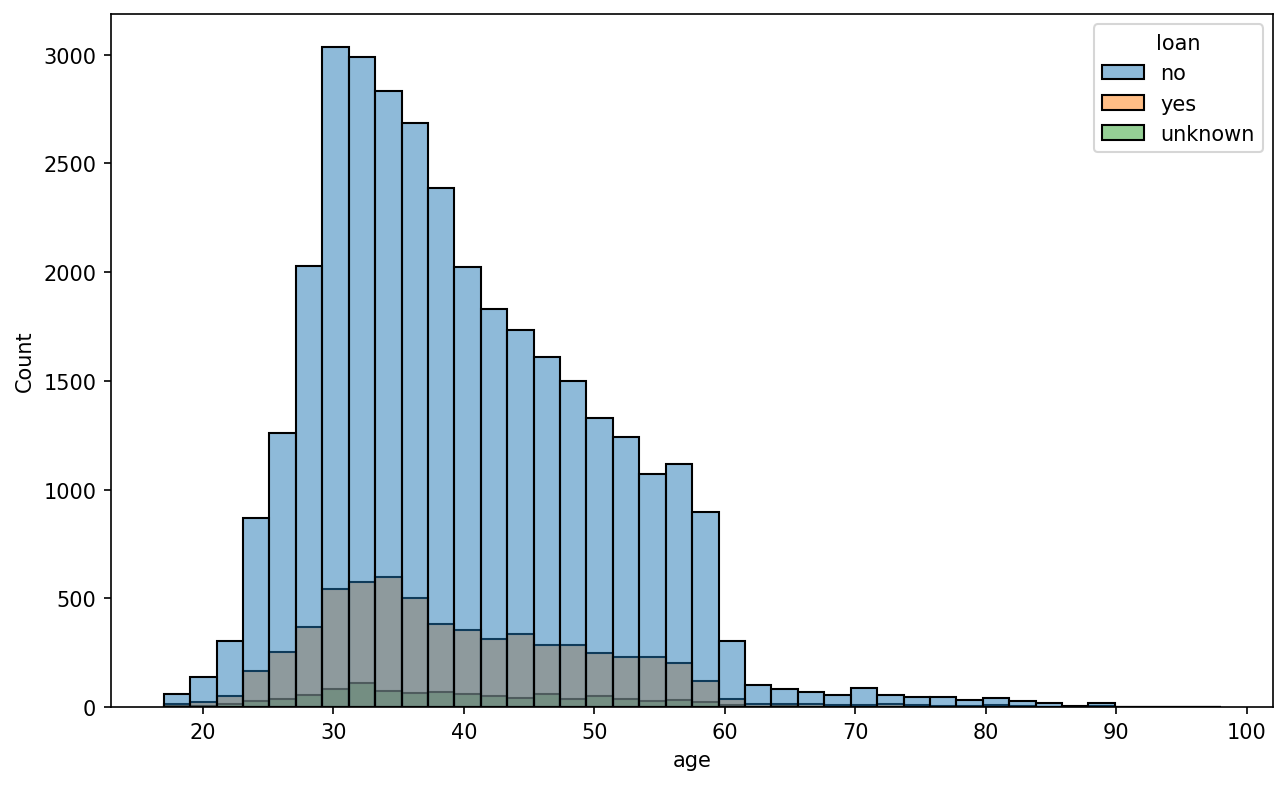

In [5]:
plt.figure(figsize=(10,6),dpi=150)
sns.histplot(data=df,x='age', bins=40, hue='loan')

### pdays
Number of days passed since last marketing campaign passed. 999="never previously contacted."

<Axes: xlabel='pdays', ylabel='Count'>

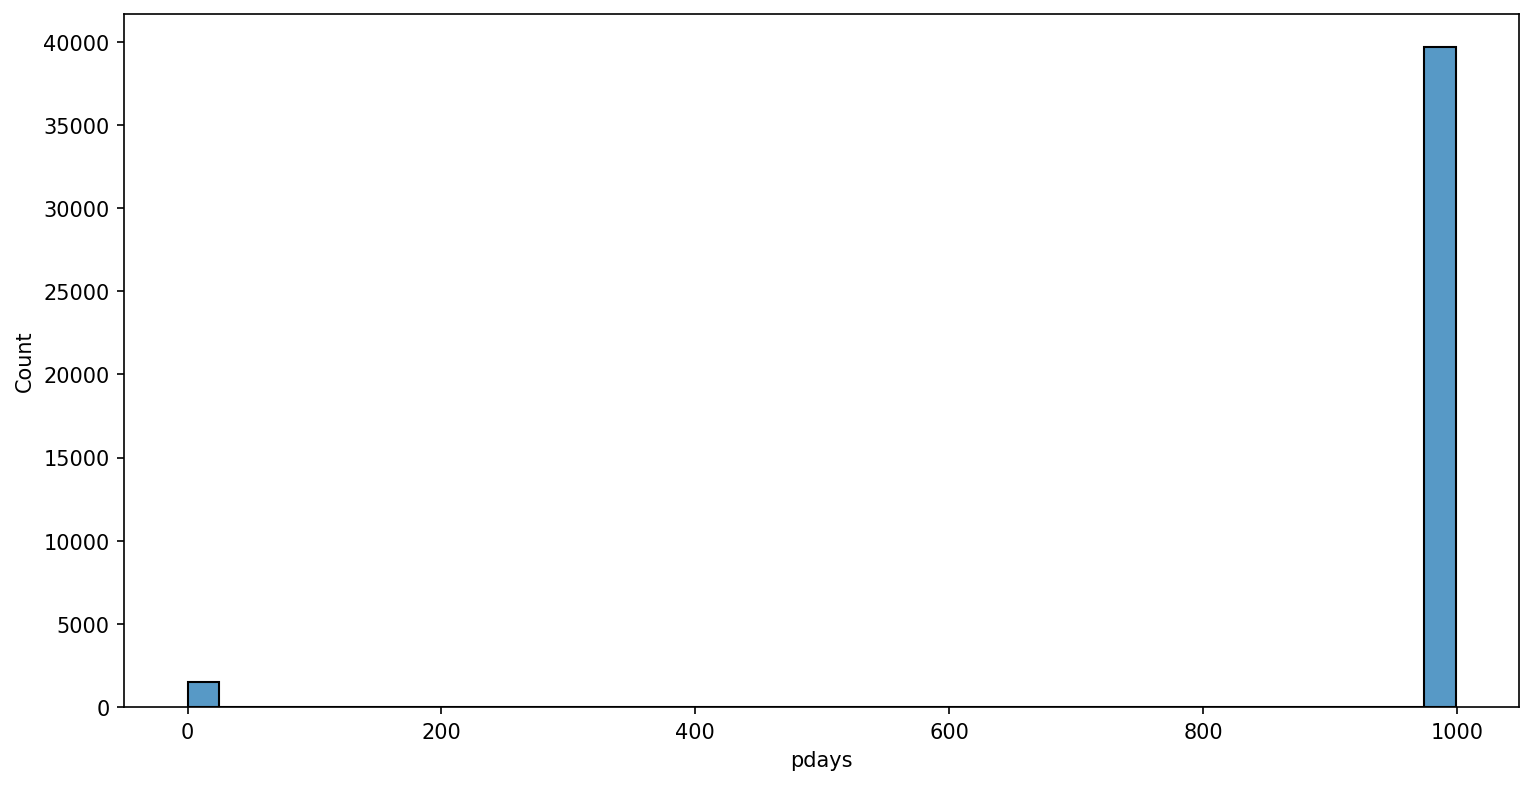

In [6]:
plt.figure(figsize=(12,6),dpi=150)
sns.histplot(data=df,x='pdays',bins=40)

Too many in the 999 side ("never previously contacted"). So let's try to exclude them from the picture

<Axes: xlabel='pdays', ylabel='Count'>

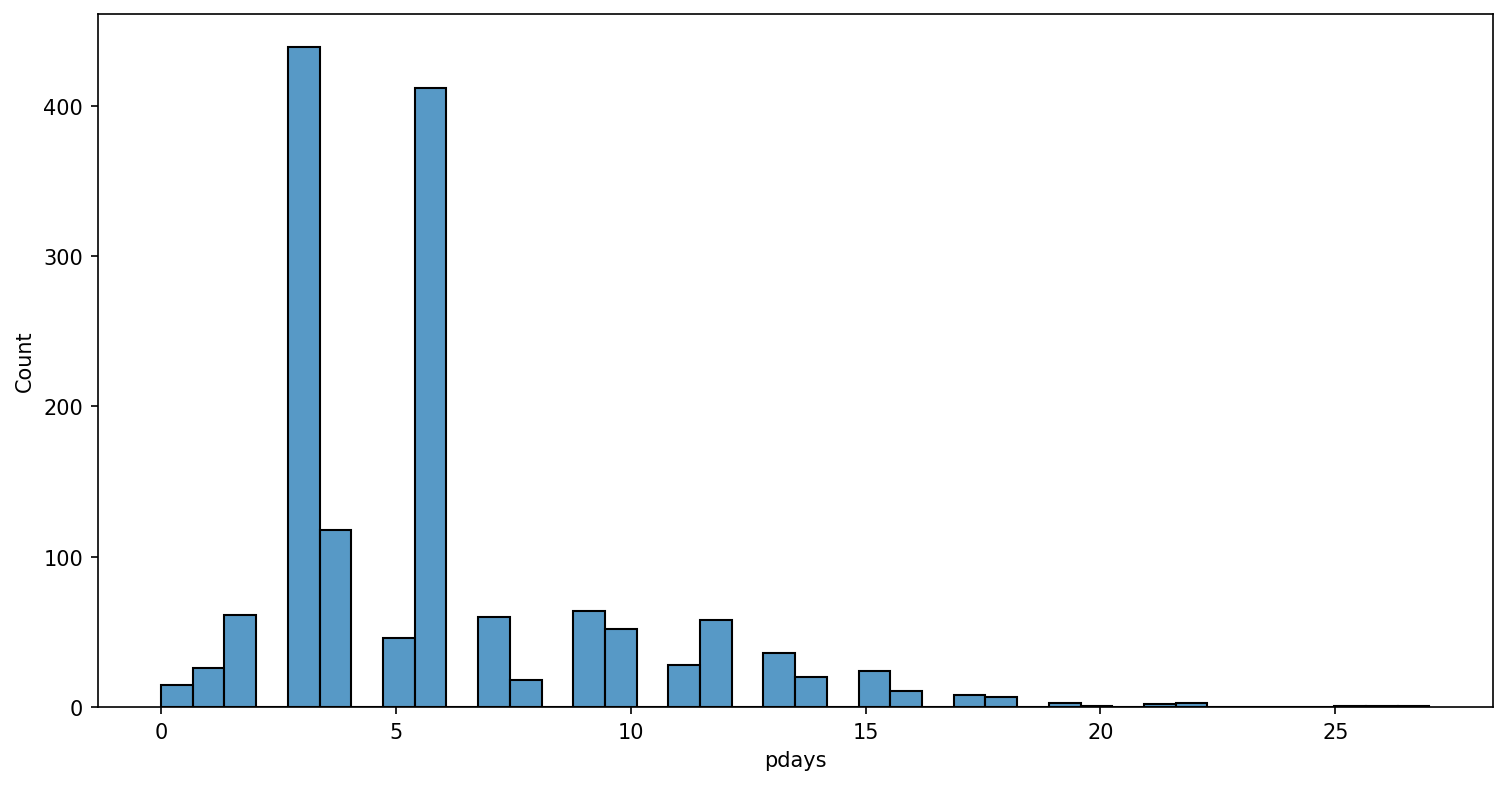

In [7]:
plt.figure(figsize=(12,6),dpi=150)
sns.histplot(data=df[df['pdays']<999],x='pdays',bins=40)

Only a litle over 800 have been contacted out of the more than 41.000 people.

In [8]:
df['contact'].unique()

<StringArray>
['telephone', 'cellular']
Length: 2, dtype: str

Text(0.5, 1.0, 'Duration of last campaign contact')

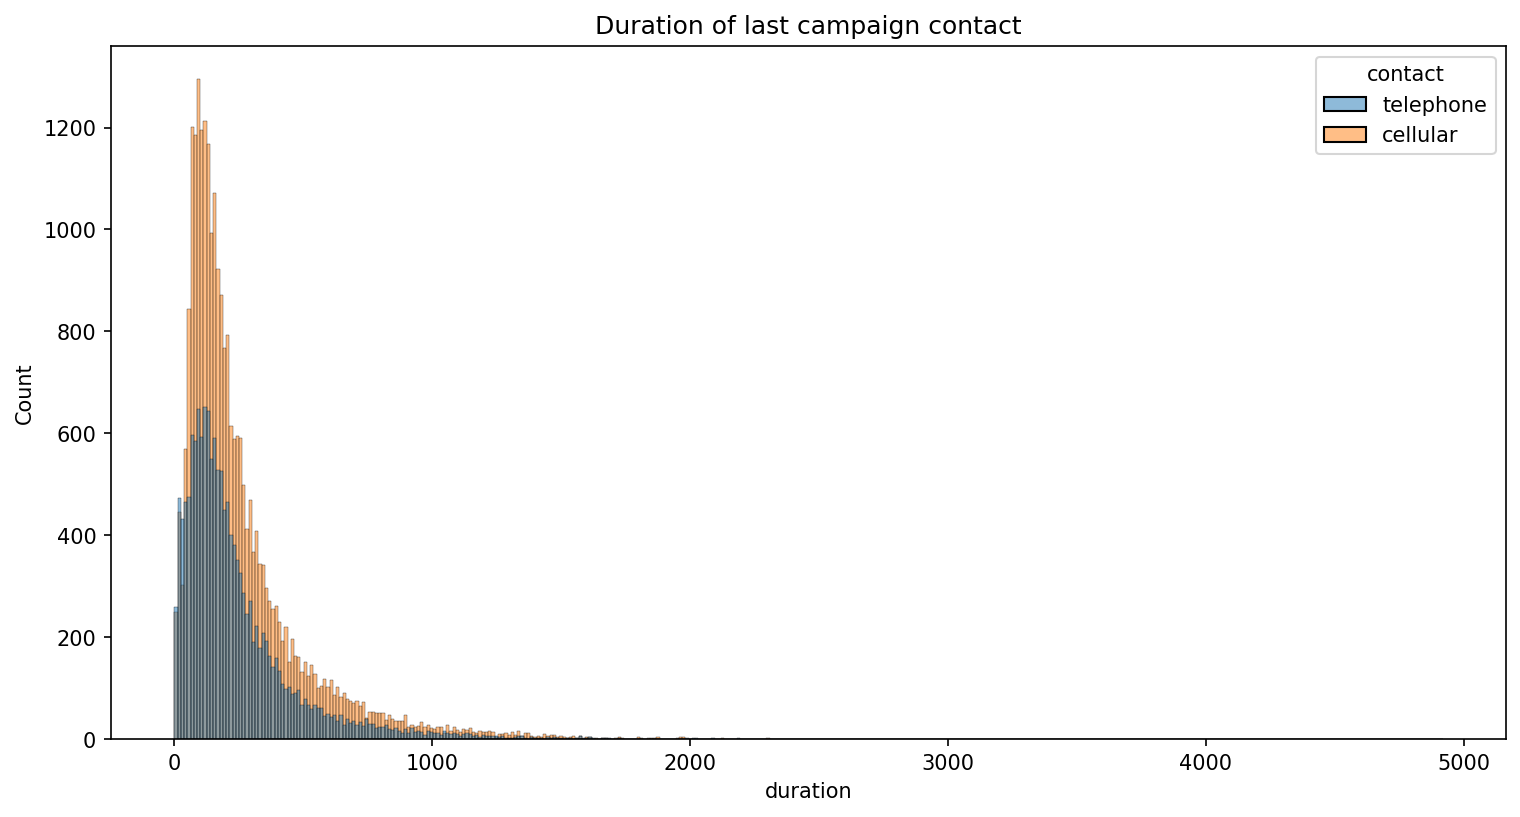

In [9]:
plt.figure(figsize=(12,6),dpi=150)
sns.histplot(data=df,x='duration',hue='contact')
plt.title("Duration of last campaign contact")

<Axes: xlabel='contact', ylabel='count'>

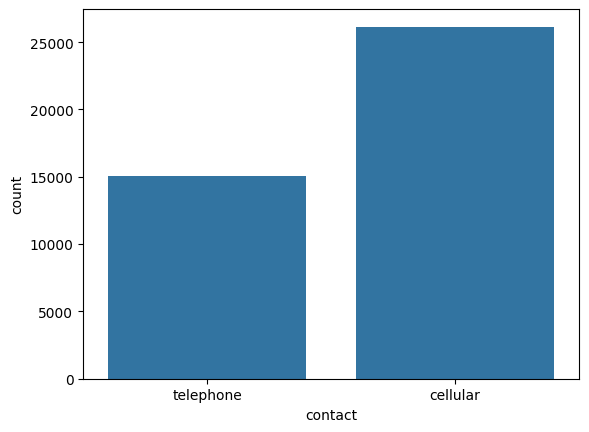

In [10]:
sns.countplot(data=df,x='contact')

In [11]:
# get the job names sorted by frequency
job_ordered_freqs=df['job'].value_counts().index

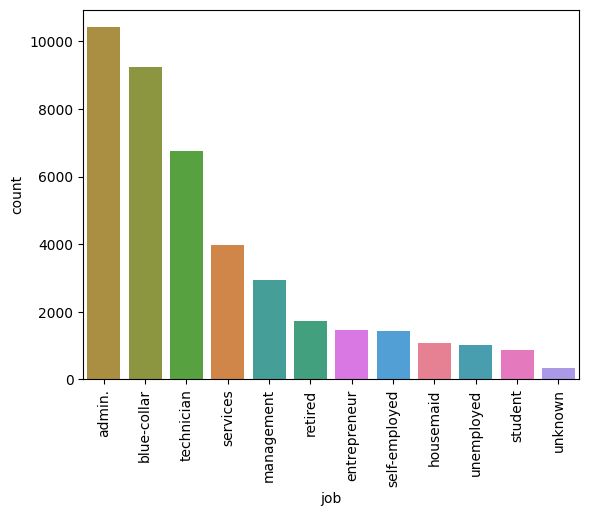

In [12]:
sns.countplot(data=df,x='job',hue='job',order=job_ordered_freqs)
plt.xticks(rotation=90);

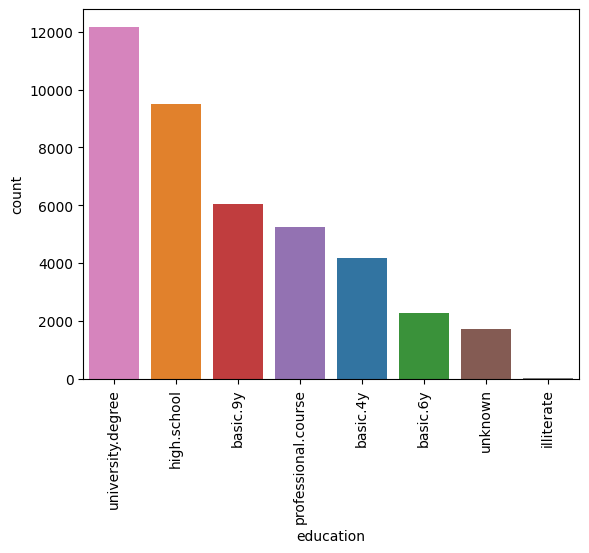

In [13]:
sns.countplot(data=df,x='education',hue='education',order=df['education'].value_counts().index)
plt.xticks(rotation=90);

# Loan status

In [14]:
df['loan'].value_counts()

loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64

In [15]:
df['default'].value_counts()

default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

Only 3 out of the 6.248 that do have a loan, have defaulted. There is a big number of unknown, which might be because they are still paying a loan and it is not yet known if they are going to default.

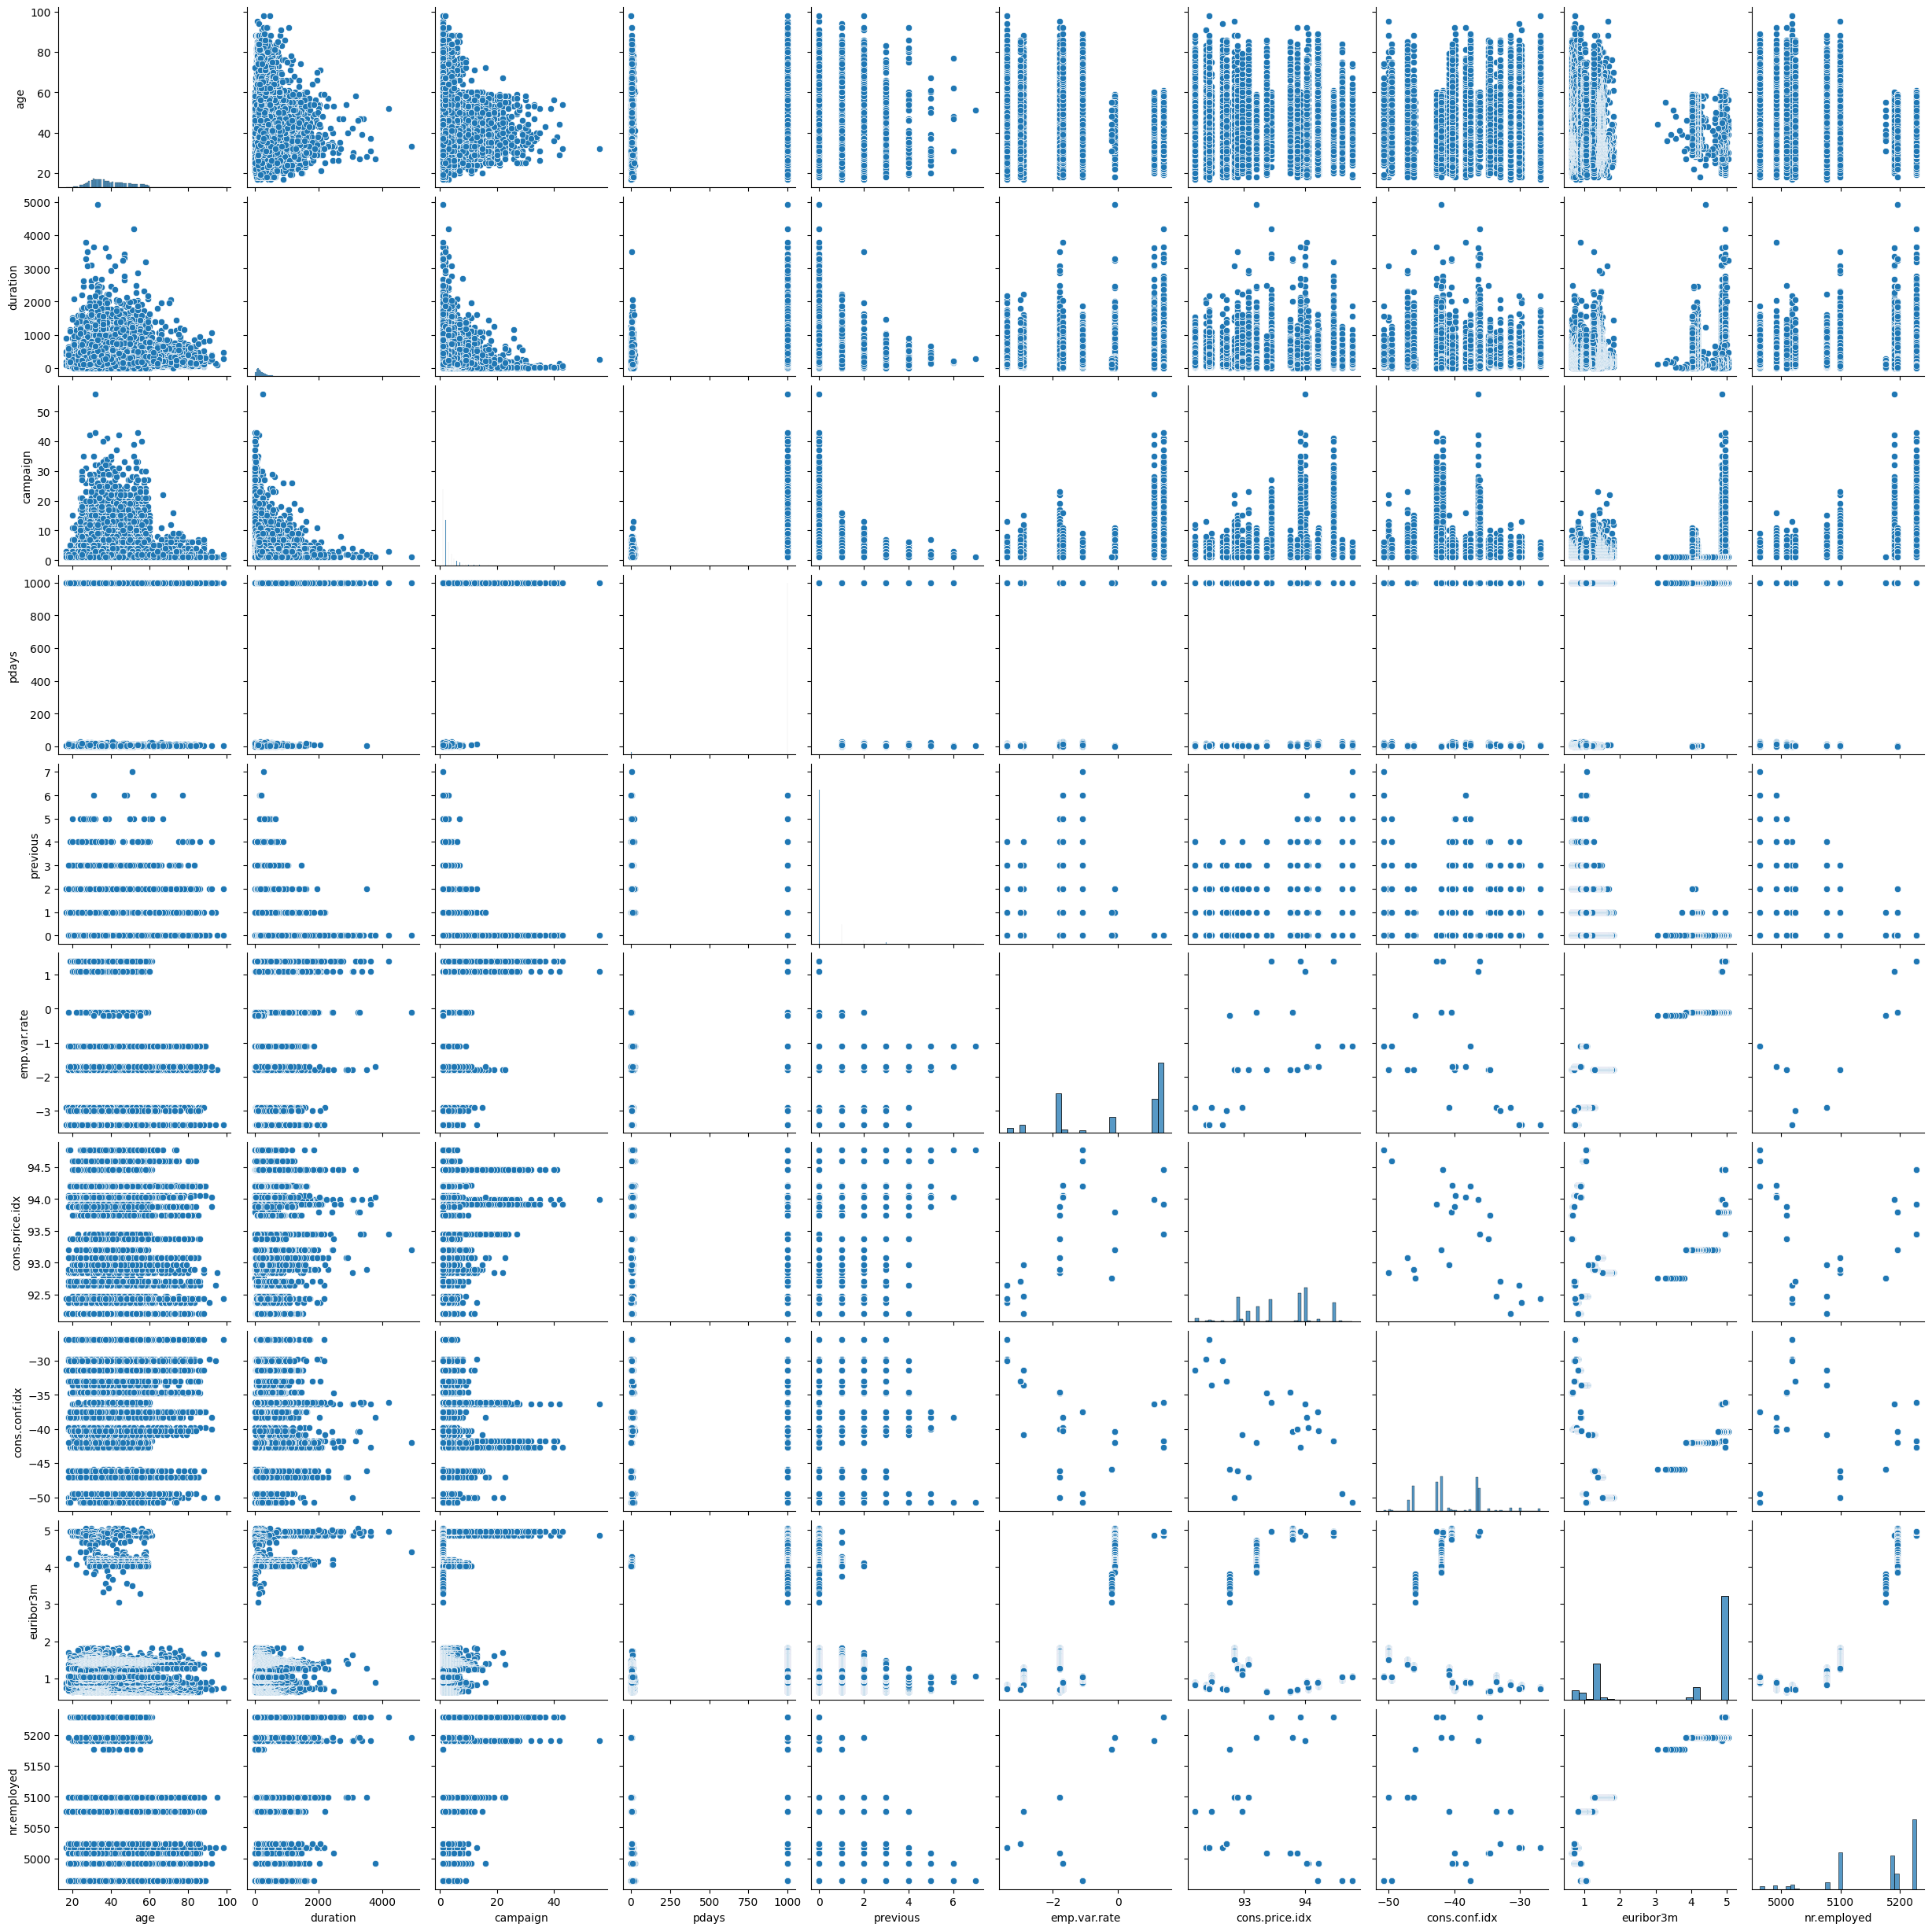

In [16]:
sns.pairplot(df)

In [17]:
X=pd.get_dummies(df)

In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
scaler=StandardScaler()

In [20]:
scaled_X=scaler.fit_transform(X)

In [21]:
from sklearn.cluster import KMeans

In [22]:
# let's assume two groups: target and not-comercial target
model=KMeans(n_clusters=2)

In [23]:
cluster_labels=model.fit_predict(scaled_X)

In [24]:
X['Cluster']=cluster_labels

In [25]:
#Check correlation between features and cluster assignments
X.corr()['Cluster'].iloc[:-1]

age                     0.019659
duration               -0.040051
campaign                0.129101
pdays                   0.267686
previous               -0.478442
                          ...   
poutcome_failure       -0.464271
poutcome_nonexistent    0.544348
poutcome_success       -0.254379
subscribed_no           0.294748
subscribed_yes         -0.294748
Name: Cluster, Length: 65, dtype: float64

In [26]:
X.corr()['Cluster'].iloc[:-1].sort_values()

previous               -0.478442
poutcome_failure       -0.464271
contact_cellular       -0.410508
month_apr              -0.357904
subscribed_yes         -0.294748
                          ...   
poutcome_nonexistent    0.544348
cons.price.idx          0.679394
nr.employed             0.886120
emp.var.rate            0.932603
euribor3m               0.959267
Name: Cluster, Length: 65, dtype: float64

<Axes: >

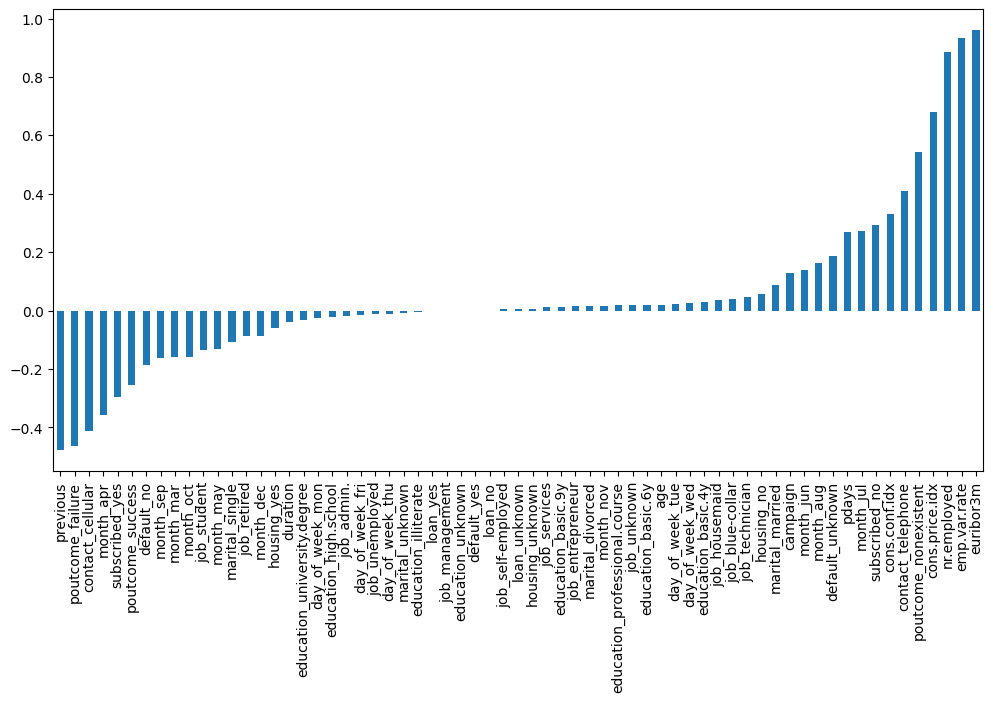

In [27]:
plt.figure(figsize=(12,6))
X.corr()['Cluster'].iloc[:-1].sort_values().plot(kind='bar')

With this graph you know which features are taken into account to make the clusters.

Knowing those features, you can use domain knowledge (yours or consulted) to see if those clusters make any distinctive sense to what you are trying to discover.

In [32]:
ssd=[]
for k in range(2,20):
    model=KMeans(n_clusters=k)
    model.fit(scaled_X)
    ssd.append(model.inertia_) # a measure of the distance from each point to the center of its cluster

In [33]:
ssd

[2469792.424502325,
 2371352.7085500546,
 2299391.1732774703,
 2221842.496257049,
 2174939.3645926784,
 2146792.2198573477,
 2061277.8857287553,
 2101605.3171143294,
 2130242.1235661916,
 1981163.9234933504,
 2001962.0314325006,
 1919385.3038944849,
 1949004.1232844407,
 1911786.472366719,
 1814006.2094368187,
 1830289.7782393203,
 1773952.5405869342,
 1722805.4243479006]

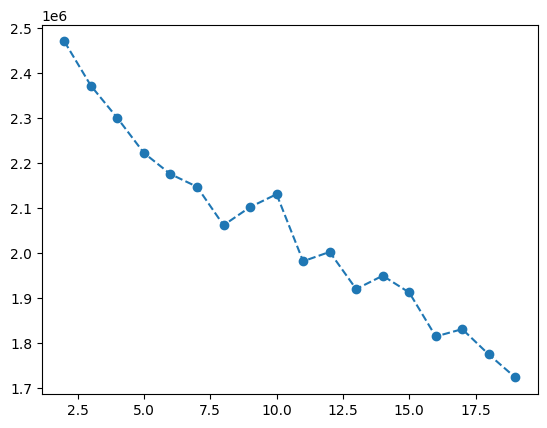

In [35]:
plt.plot(range(2,20),ssd,'o--')

In [36]:
pd.Series(ssd)

0     2.469792e+06
1     2.371353e+06
2     2.299391e+06
3     2.221842e+06
4     2.174939e+06
5     2.146792e+06
6     2.061278e+06
7     2.101605e+06
8     2.130242e+06
9     1.981164e+06
10    2.001962e+06
11    1.919385e+06
12    1.949004e+06
13    1.911786e+06
14    1.814006e+06
15    1.830290e+06
16    1.773953e+06
17    1.722805e+06
dtype: float64

In [37]:
pd.Series(ssd).diff()

0               NaN
1     -98439.715952
2     -71961.535273
3     -77548.677020
4     -46903.131664
5     -28147.144735
6     -85514.334129
7      40327.431386
8      28636.806452
9    -149078.200073
10     20798.107939
11    -82576.727538
12     29618.819390
13    -37217.650918
14    -97780.262930
15     16283.568803
16    -56337.237652
17    -51147.116239
dtype: float64

# Color Quantization
This method can be applied to color quantization.

One image in RGB can be thought of as a series of observations of three features: R, G and B.

When you need to reduce the range of colors to 32, 16, 8 . . . you start with that number as the desired number of clusters and fit the model to the image data. What you obtain as clusters are groups of shades that are "close enough" to be considered one color. Then you assign to each data point the values of the center of its cluster and you have reduced the image to the number of colors equal to the number of clusters.

In [38]:
import matplotlib.image as mpimg

In [40]:
image_as_array=mpimg.imread('../../jupyter_notebooks/DATA/palm_trees.jpg')

In [41]:
image_as_array.shape # (height, width, colors)

(1401, 934, 3)

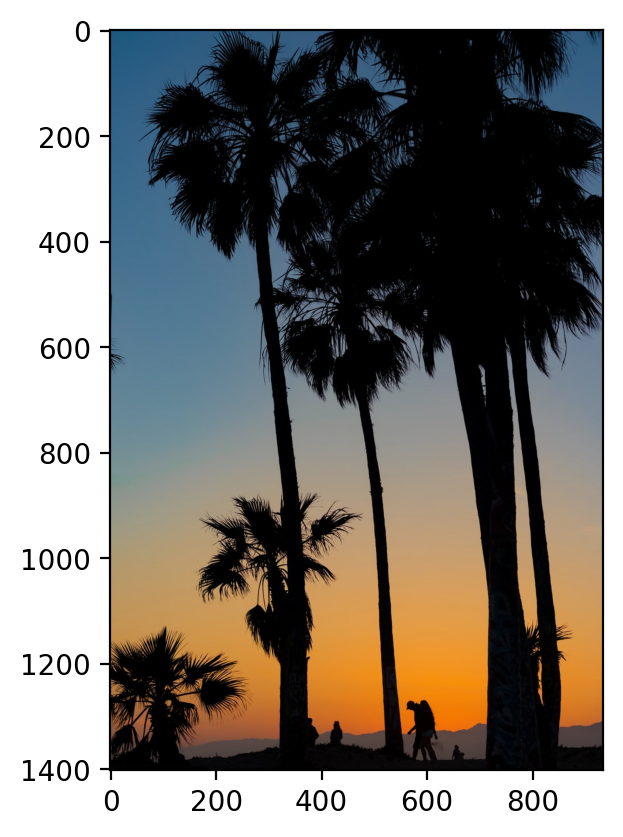

In [42]:
plt.figure(dpi=200)
plt.imshow(image_as_array)

We will convert this from (3D: Height, width, colors) to (2D: Height*Width, colors)

In [43]:
h,w,c=image_as_array.shape

In [44]:
image_as_array2d=image_as_array.reshape(h*w,c)

In [45]:
model=KMeans(n_clusters=6)

In [46]:
labels=model.fit_predict(image_as_array2d)

In [47]:
labels

array([2, 2, 2, ..., 1, 1, 1], shape=(1308534,), dtype=int32)

In [48]:
model.cluster_centers_

array([[192.55765598, 154.49309998, 108.35512522],
       [  2.78924964,   2.59218008,   3.70531318],
       [ 71.70130246, 109.59505587, 137.74965366],
       [137.99262808, 144.12994278, 143.55204258],
       [ 67.74732454,  61.97421892,  62.19566439],
       [219.28399746, 135.14157972,  46.25810165]])

In [49]:
rgb_codes=model.cluster_centers_.round(0).astype(int)
rgb_codes

array([[193, 154, 108],
       [  3,   3,   4],
       [ 72, 110, 138],
       [138, 144, 144],
       [ 68,  62,  62],
       [219, 135,  46]])

In [51]:
rgb_codes[labels]

array([[ 72, 110, 138],
       [ 72, 110, 138],
       [ 72, 110, 138],
       ...,
       [  3,   3,   4],
       [  3,   3,   4],
       [  3,   3,   4]], shape=(1308534, 3))

In [54]:
quantized_images=np.reshape(rgb_codes[labels],(h,w,c))

In [55]:
quantized_images.shape

(1401, 934, 3)

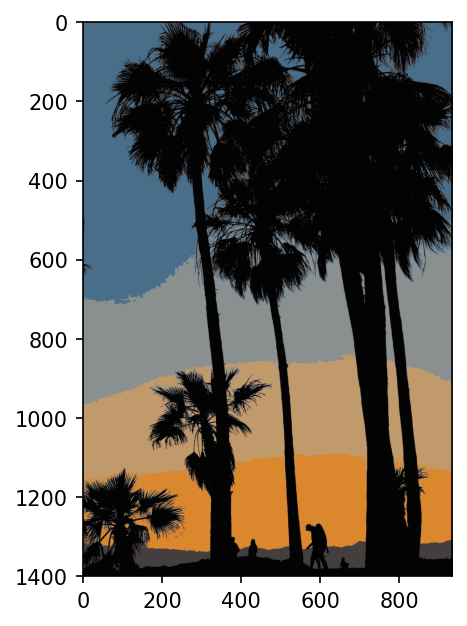

In [58]:
plt.figure(dpi=150)
plt.imshow(quantized_images)